![image.png](https://i.imgur.com/a3uAqnb.png)

# Logistic Regression for Titanic Survival Prediction - Homework Assignment

In this homework, you will implement a **Logistic Regression classifier** to predict passenger survival on the Titanic. This project will help you understand the fundamentals of classification using logistic regression.

## 📌 Project Overview
- **Task**: Predict passenger survival on the Titanic
- **Algorithm**: Logistic Regression for binary classification
- **Dataset**: Titanic passenger dataset (provided)
- **Goal**: Build an accurate classification model using scikit-learn

## 📚 Learning Objectives
By completing this assignment, you will:
- Understand logistic regression for binary classification problems
- Learn data preprocessing and feature engineering techniques
- Practice exploratory data analysis (EDA)
- Implement feature selection and model evaluation
- Learn about classification metrics and model performance
- Identify the most important features for survival prediction

## 1️⃣ Initial Setup and Library Installation

**Task**: Set up the environment and install necessary libraries.

In [ ]:
from IPython.display import clear_output

## 2️⃣ Library Installation (if needed)

**Task**: Install required libraries for the project.

In [ ]:
# Incase you run this notebook outside colab (where the libraries aren't already pre-installed)

# %pip install numpy
# %pip install pandas
# %pip install matplotlib
# %pip install seaborn
# %pip install scikit-learn

clear_output()

## 3️⃣ Import Libraries and Configuration

**Task**: Import all necessary libraries and set up configuration parameters.

**Requirements**:
- Import data processing libraries (pandas, numpy)
- Import visualization libraries (matplotlib, seaborn)
- Import scikit-learn modules for preprocessing and modeling
- Set random seeds for reproducibility
- Configure display options for better data visualization

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Configure matplotlib
plt.style.use('default')
sns.set_palette("husl")

#ADD
import os

## 4️⃣ Data Loading and Initial Exploration

**Task**: Load the Titanic dataset and perform initial exploration.

**Requirements**:
- Download and load the dataset
- Display basic information about the data
- Check data types and structure
- Identify the target variable and features

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset") # Titanic-Dataset.csv

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


In [ ]:
# TODO: Load the Titanic dataset
titanic_data = pd.read_csv(os.path.join(path, 'Titanic-Dataset.csv'))

# TODO: Display basic information about the dataset
'''
completed in the next box
'''

'\ncompleted in the next box\n'

## 5️⃣ Exploratory Data Analysis (EDA)

**Task**: Perform comprehensive exploratory data analysis to understand the data.

**Requirements**:
- Examine data structure and missing values
- Analyze the distribution of the target variable
- Explore relationships between features and survival
- Create visualizations to understand data patterns

In [ ]:
# TODO: Display first few rows of the dataset
display(titanic_data.head())

# TODO: Get basic information about the dataset (shape, data types)
display(titanic_data.info())

# TODO: Check for missing values
print(titanic_data.isna().head())
print(titanic_data.isna().sum())

# TODO: Display statistical summary of numerical features
display(titanic_data.describe())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


None

   PassengerId  Survived  Pclass   Name    Sex    Age  SibSp  Parch  Ticket  \
0        False     False   False  False  False  False  False  False   False   
1        False     False   False  False  False  False  False  False   False   
2        False     False   False  False  False  False  False  False   False   
3        False     False   False  False  False  False  False  False   False   
4        False     False   False  False  False  False  False  False   False   

    Fare  Cabin  Embarked  
0  False   True     False  
1  False  False     False  
2  False   True     False  
3  False  False     False  
4  False   True     False  
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


,count
Survived,
0,549
1,342


,proportion
Survived,
0,61.616162
1,38.383838


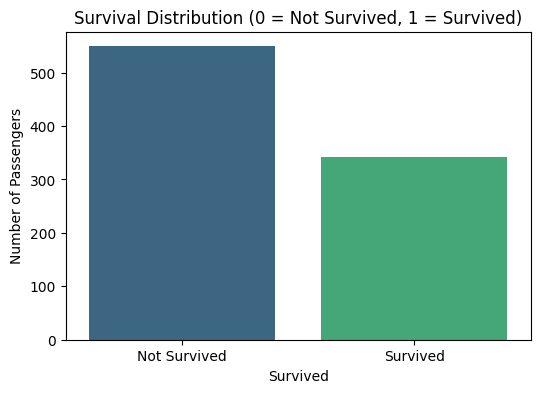

In [ ]:
# TODO: Analyze the target variable distribution (Survived)
display(titanic_data['Survived'].value_counts())
display(titanic_data['Survived'].value_counts(normalize=True) * 100) # the percentage for each

# TODO: Create visualizations for survival distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=titanic_data, palette='viridis')
plt.title('Survival Distribution (0 = Not Survived, 1 = Survived)')
plt.xlabel('Survived')
plt.ylabel('Number of Passengers')
plt.xticks([0, 1], ['Not Survived', 'Survived'])
plt.show()

Survival rate by Sex:


,Sex,Survived
0,female,0.742038
1,male,0.188908


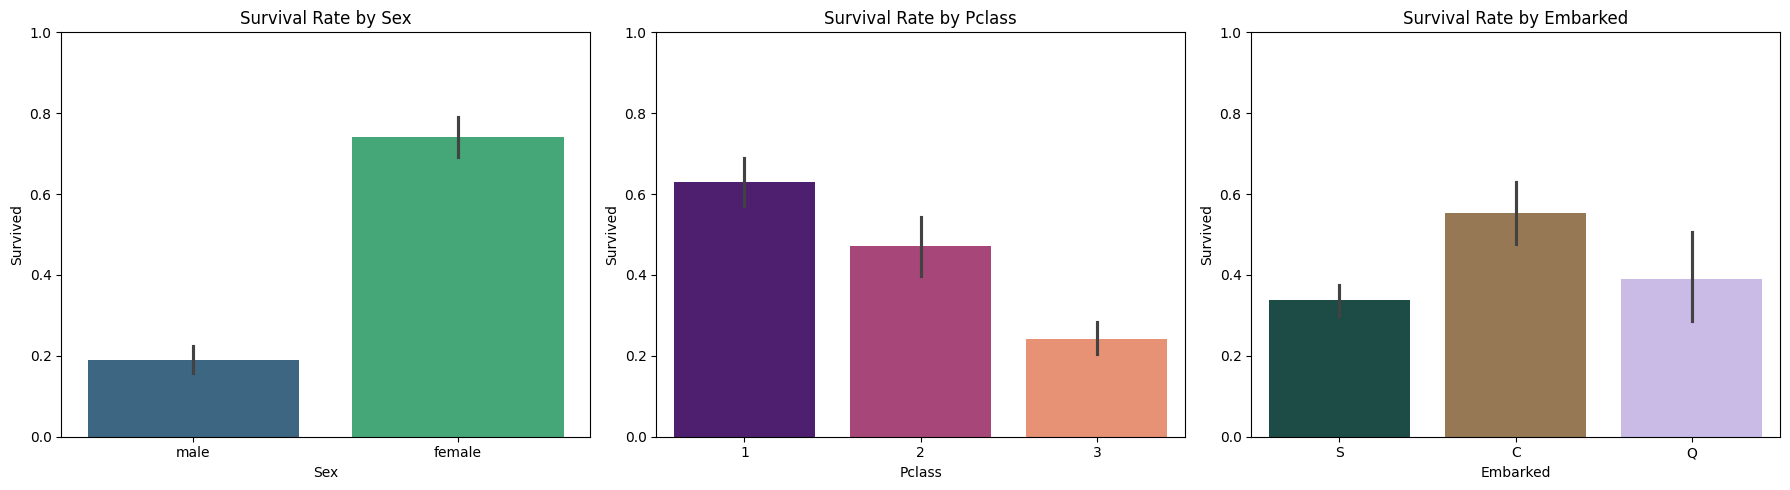

In [ ]:
# TODO: Explore survival rates by different categorical features (Sex, Pclass, Embarked)
# Calculate survival rate by Sex
survival_by_sex = titanic_data.groupby('Sex')['Survived'].mean().reset_index() # .reset_index() for returingt to default index
print("Survival rate by Sex:")
display(survival_by_sex)

# TODO: Create plots to visualize survival rates
plt.figure(figsize=(18, 5))

# Plot 1: Survival by Sex
plt.subplot(1, 3, 1)
sns.barplot(x='Sex', y='Survived', data=titanic_data, palette='viridis')
plt.title('Survival Rate by Sex')
plt.ylim(0, 1)

# Plot 2: Survival by Pclass
plt.subplot(1, 3, 2)
sns.barplot(x='Pclass', y='Survived', data=titanic_data, palette='magma')
plt.title('Survival Rate by Pclass')
plt.ylim(0, 1)

# Plot 3: Survival by Embarked
plt.subplot(1, 3, 3)
sns.barplot(x='Embarked', y='Survived', data=titanic_data, palette='cubehelix')
plt.title('Survival Rate by Embarked')
plt.ylim(0, 1)

plt.tight_layout()
plt.show()


Summary Statistics for Numerical Features:


,Age,Fare,SibSp,Parch
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,32.204208,0.523008,0.381594
std,14.526497,49.693429,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,7.910400,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,38.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


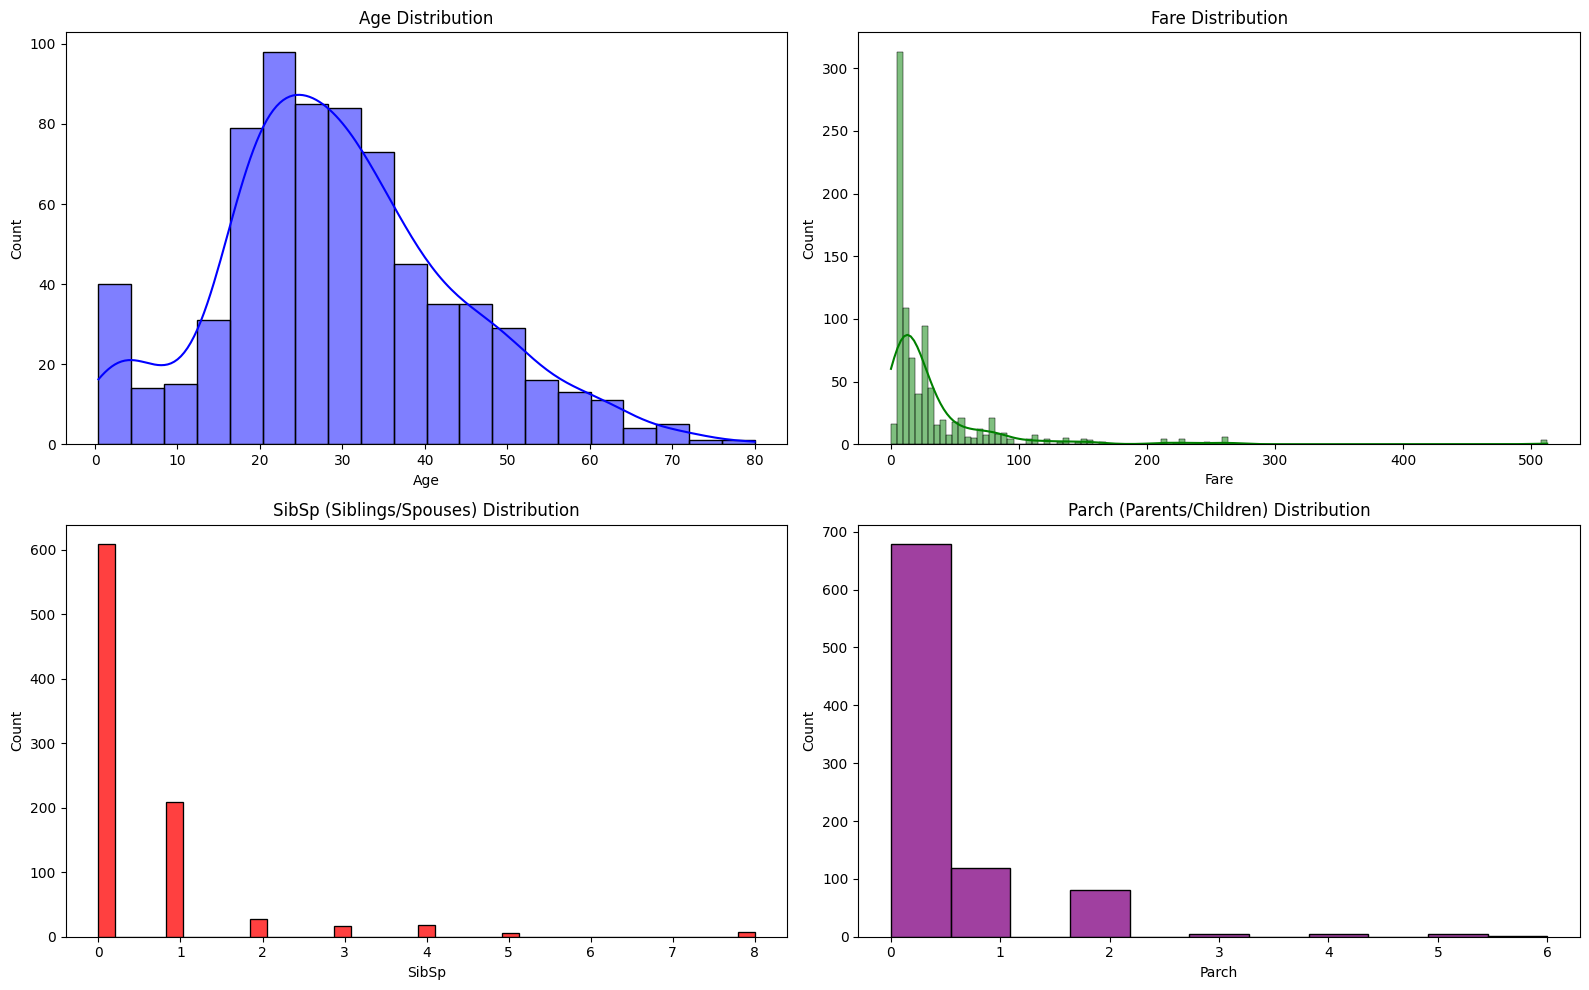

Survival Rates by Age Group:


,AgeBin,Survived
0,"(0, 12]",0.579710
1,"(12, 18]",0.428571
2,"(18, 35]",0.382682
3,"(35, 60]",0.400000
4,"(60, 80]",0.227273



Survival Rates by Fare Range:


,FareBin,Survived
0,"(-0.001, 7.91]",0.197309
1,"(7.91, 14.454]",0.303571
2,"(14.454, 31.0]",0.454955
3,"(31.0, 512.329]",0.581081


In [ ]:
# TODO: Analyze numerical features (Age, Fare, SibSp, Parch)
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']
print("Summary Statistics for Numerical Features:")
display(titanic_data[numerical_cols].describe())

# TODO: Create histograms for numerical features
plt.figure(figsize=(16, 10))

# Plot Age distribution
plt.subplot(2, 2, 1)
sns.histplot(titanic_data['Age'].dropna(), kde=True, color='blue')
plt.title('Age Distribution')

# Plot Fare distribution
plt.subplot(2, 2, 2)
sns.histplot(titanic_data['Fare'], kde=True, color='green')
plt.title('Fare Distribution')

# Plot SibSp distribution
plt.subplot(2, 2, 3)
sns.histplot(titanic_data['SibSp'], kde=False, color='red')
plt.title('SibSp (Siblings/Spouses) Distribution')

# Plot Parch distribution
plt.subplot(2, 2, 4)
sns.histplot(titanic_data['Parch'], kde=False, color='purple')
plt.title('Parch (Parents/Children) Distribution')

plt.tight_layout()
plt.show()

# TODO: Examine survival rates across different age groups and fare ranges
# 1. Create Age groups and calculate survival rates
titanic_data['AgeBin'] = pd.cut(titanic_data['Age'], bins=[0, 12, 18, 35, 60, 80])
survival_by_agebin = titanic_data.groupby('AgeBin')['Survived'].mean().reset_index()
print("Survival Rates by Age Group:")
display(survival_by_agebin)

# 2. Create Fare ranges (using quartiles) and calculate survival rates
titanic_data['FareBin'] = pd.qcut(titanic_data['Fare'], 4)
survival_by_farebin = titanic_data.groupby('FareBin')['Survived'].mean().reset_index()
print("\nSurvival Rates by Fare Range:")
display(survival_by_farebin)

## 6️⃣ Data Preprocessing and Feature Engineering

**Task**: Clean and prepare the data for logistic regression modeling.

**Requirements**:
- Handle missing values appropriately
- Encode categorical variables
- Create new features if beneficial
- Scale numerical features if necessary
- Select relevant features for modeling

In [ ]:
# TODO: Create a copy of the dataset for preprocessing
titanic_processed = titanic_data.copy()

# TODO: Handle missing values
# - Fill missing Age values (consider using median or mean)
titanic_processed['Age'] = titanic_processed['Age'].fillna(titanic_processed['Age'].median())

# - Fill missing Embarked values (consider using mode)
embarked_mode = titanic_processed['Embarked'].mode()[0] # 0-index --> the most frequent
titanic_processed['Embarked'] = titanic_processed['Embarked'].fillna(embarked_mode)

# - Handle missing Cabin values (consider creating a binary feature)
titanic_processed['HasCabin'] = titanic_processed['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)
'''
  1. lambda: define a function only using once
  2. .apply() work as a for-loop
'''

# TODO: Feature engineering
# - Create FamilySize feature from SibSp and Parch
titanic_processed['FamilySize'] = titanic_processed['SibSp'] + titanic_processed['Parch'] + 1

# - Create IsAlone feature
titanic_processed['IsAlone'] = titanic_processed['FamilySize'].apply(lambda x: 1 if x == 1 else 0)

# - Create Age groups or Fare groups if beneficial
titanic_processed['AgeBin'] = pd.cut(titanic_processed['Age'], bins=[0, 12, 18, 35, 60, 80])
titanic_processed['FareBin'] = pd.qcut(titanic_processed['Fare'], 4)

# check
display(titanic_processed.head())
print(titanic_processed.isna().sum())



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeBin,FareBin,HasCabin,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,"(18, 35]","(-0.001, 7.91]",0,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,"(35, 60]","(31.0, 512.329]",1,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,"(18, 35]","(7.91, 14.454]",0,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,"(18, 35]","(31.0, 512.329]",1,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,"(18, 35]","(7.91, 14.454]",0,1,1


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
AgeBin           0
FareBin          0
HasCabin         0
FamilySize       0
IsAlone          0
dtype: int64


In [ ]:
# TODO: Encode categorical variables
# - Convert Sex to numerical values
titanic_processed['Sex'] = titanic_processed['Sex'].map({'female': 1, 'male': 0})

# - Encode Embarked using appropriate method （one-hot encoding）
titanic_processed = pd.get_dummies(titanic_processed, columns=['Embarked'], prefix='Embarked')

# - Handle any other categorical features
'''
there is no other categorical features
'''

# TODO: Drop irrelevant columns (Name, PassengerId, Ticket, etc.)
columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'AgeBin', 'FareBin']
titanic_final = titanic_processed.drop(columns=columns_to_drop)

# TODO: Verify the processed dataset
display(titanic_final.shape)
display(titanic_final.head())
display(titanic_final.info())
display(titanic_final.isna().sum())

(891, 13)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,FamilySize,IsAlone,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,2,0,False,False,True
1,1,1,1,38.0,1,0,71.2833,1,2,0,True,False,False
2,1,3,1,26.0,0,0,7.9250,0,1,1,False,False,True
3,1,1,1,35.0,1,0,53.1000,1,2,0,False,False,True
4,0,3,0,35.0,0,0,8.0500,0,1,1,False,False,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   HasCabin    891 non-null    int64  
 8   FamilySize  891 non-null    int64  
 9   IsAlone     891 non-null    int64  
 10  Embarked_C  891 non-null    bool   
 11  Embarked_Q  891 non-null    bool   
 12  Embarked_S  891 non-null    bool   
dtypes: bool(3), float64(2), int64(8)
memory usage: 72.3 KB


None

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
HasCabin,0
FamilySize,0
IsAlone,0


## 7️⃣ Feature Selection and Data Splitting

**Task**: Select the most relevant features and split the data for training and testing.

**Requirements**:
- Separate features (X) from target variable (y)
- Split data into training and testing sets (80:20 ratio)
- Apply feature scaling if necessary
- Ensure no data leakage

In [ ]:
# TODO: Separate features from target variable
# X = features, y = target (Survived)
X = titanic_final.drop('Survived', axis=1)
y = titanic_final['Survived']

# TODO: Split the data into training and testing sets (80:20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TODO: Apply feature scaling if necessary (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# TODO: Display the shapes of training and testing sets
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (712, 12)
Shape of y_train: (712,)
Shape of X_test: (179, 12)
Shape of y_test: (179,)


## 8️⃣ Logistic Regression Model Training

**Task**: Train a logistic regression model on the training data.

**Requirements**:
- Initialize LogisticRegression with appropriate parameters
- Fit the model on training data
- Use cross-validation if needed

In [ ]:
# TODO: Initialize the Logistic Regression model
# Consider parameters like random_state, max_iter
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# TODO: Train the model on training data
log_reg.fit(X_train_scaled, y_train)

# TODO: Display model parameters and coefficients
print("Model training completed.")
print(f"Intercept: {log_reg.intercept_[0]:.4f}")

# Create a DataFrame to view coefficients clearly
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\nModel Coefficients:")
display(coefficients)

Model training completed.
Intercept: -0.6867

Model Coefficients:


,Feature,Coefficient
1,Sex,1.254500
6,HasCabin,0.263521
5,Fare,0.081605
9,Embarked_C,0.075607
10,Embarked_Q,0.016373
11,Embarked_S,-0.075962
4,Parch,-0.086497
7,FamilySize,-0.280860
8,IsAlone,-0.321542
3,SibSp,-0.343485


## 9️⃣ Model Evaluation and Performance Analysis

**Task**: Evaluate the trained model on both training and testing data.

**Requirements**:
- Make predictions on both training and testing sets
- Calculate various classification metrics
- Create confusion matrix
- Analyze model performance and potential overfitting

,Accuracy,Precision,Recall,F1 Score
Training Set,0.807584,0.767347,0.701493,0.732943
Testing Set,0.804469,0.782609,0.729730,0.755245



Classification Report (Testing Set):
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



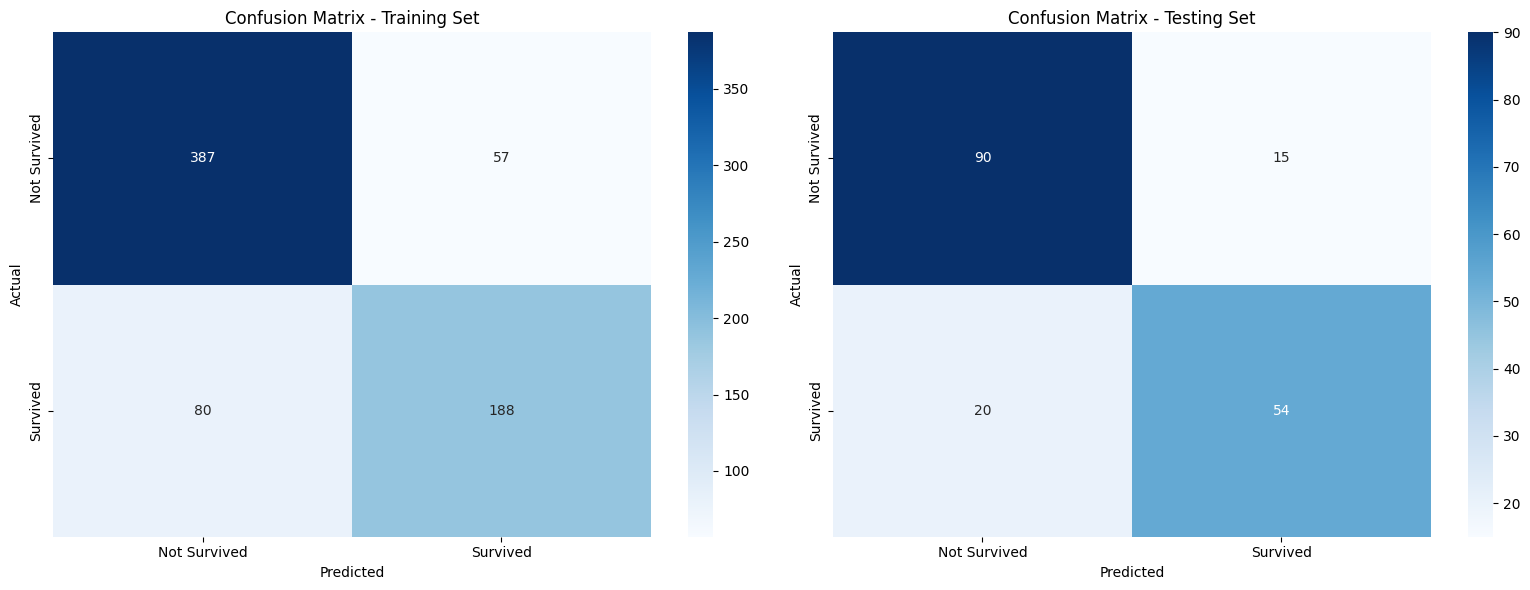

In [ ]:
# TODO: Make predictions on training and testing sets
y_train_pred = log_reg.predict(X_train_scaled)
y_test_pred = log_reg.predict(X_test_scaled)

# TODO: Calculate accuracy, precision, recall, and F1-score for both sets
metrics = {
    'Accuracy': [accuracy_score(y_train, y_train_pred), accuracy_score(y_test, y_test_pred)],
    'Precision': [precision_score(y_train, y_train_pred), precision_score(y_test, y_test_pred)],
    'Recall': [recall_score(y_train, y_train_pred), recall_score(y_test, y_test_pred)],
    'F1 Score': [f1_score(y_train, y_train_pred), f1_score(y_test, y_test_pred)]
}

metrics_df = pd.DataFrame(metrics, index=['Training Set', 'Testing Set'])
display(metrics_df)

# TODO: Display classification report
print("\nClassification Report (Testing Set):")
print(classification_report(y_test, y_test_pred))

# TODO: Create and visualize confusion matrix
# Create and visualize confusion matrix for both training and testing sets
plt.figure(figsize=(16, 6)) # Increased figure size to accommodate two plots

# Plot 1: Confusion Matrix for Training Set
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
cm_train = confusion_matrix(y_train, y_train_pred)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Training Set')

# Plot 2: Confusion Matrix for Testing Set
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Testing Set')

plt.tight_layout()
plt.show()



Accuracy Difference (Train - Test): 0.0031


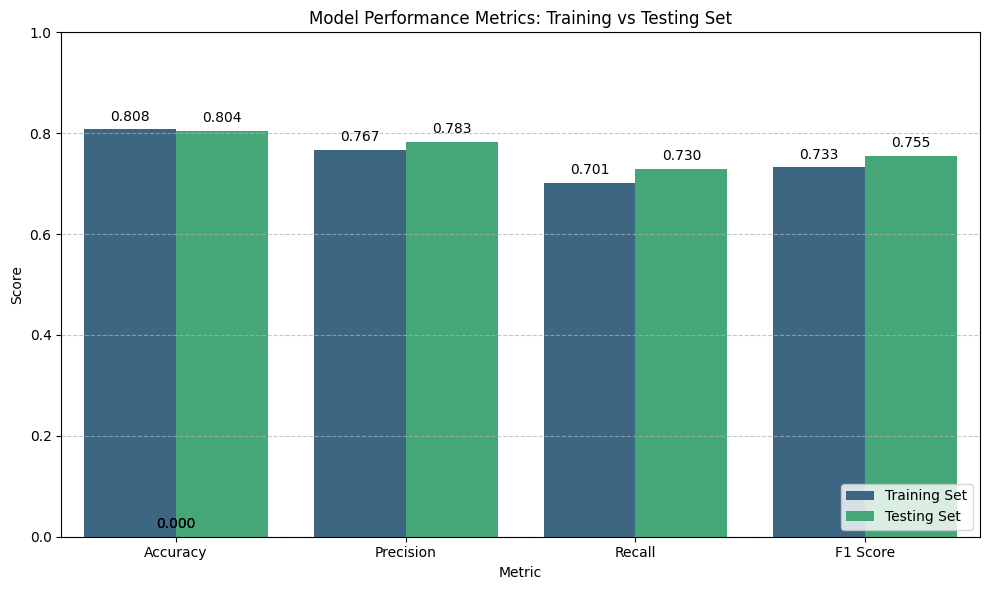

In [ ]:
# TODO: Create a comprehensive performance comparison
# Compare training vs testing performance to check for overfitting
'''
comparison already done in the previous box
'''
# check overfitting
acc_diff = metrics_df.loc['Training Set', 'Accuracy'] - metrics_df.loc['Testing Set', 'Accuracy']
print(f"\nAccuracy Difference (Train - Test): {acc_diff:.4f}")

# TODO: Visualize model performance metrics
metrics_melted = metrics_df.reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')
metrics_melted.columns = ['Dataset', 'Metric', 'Score']

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Dataset', data=metrics_melted, palette='viridis')
plt.title('Model Performance Metrics: Training vs Testing Set')
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels on bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.3f}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center',
                   xytext=(0, 9),
                   textcoords='offset points')

plt.tight_layout()
plt.show()


<font color='red'> **train-test difference very small --> no overfitting** </font>

## 🔟 Feature Importance Analysis

**Task**: Analyze which features most strongly influence passenger survival.

**Requirements**:
- Extract and interpret model coefficients
- Rank features by importance
- Create visualizations for feature importance
- Provide insights about survival factors

Feature Ranking (by absolute influence):


,Feature,Coefficient,Abs_Coefficient
1,Sex,1.254500,1.254500
0,Pclass,-0.570933,0.570933
2,Age,-0.390112,0.390112
3,SibSp,-0.343485,0.343485
8,IsAlone,-0.321542,0.321542
7,FamilySize,-0.280860,0.280860
6,HasCabin,0.263521,0.263521
4,Parch,-0.086497,0.086497
5,Fare,0.081605,0.081605
11,Embarked_S,-0.075962,0.075962


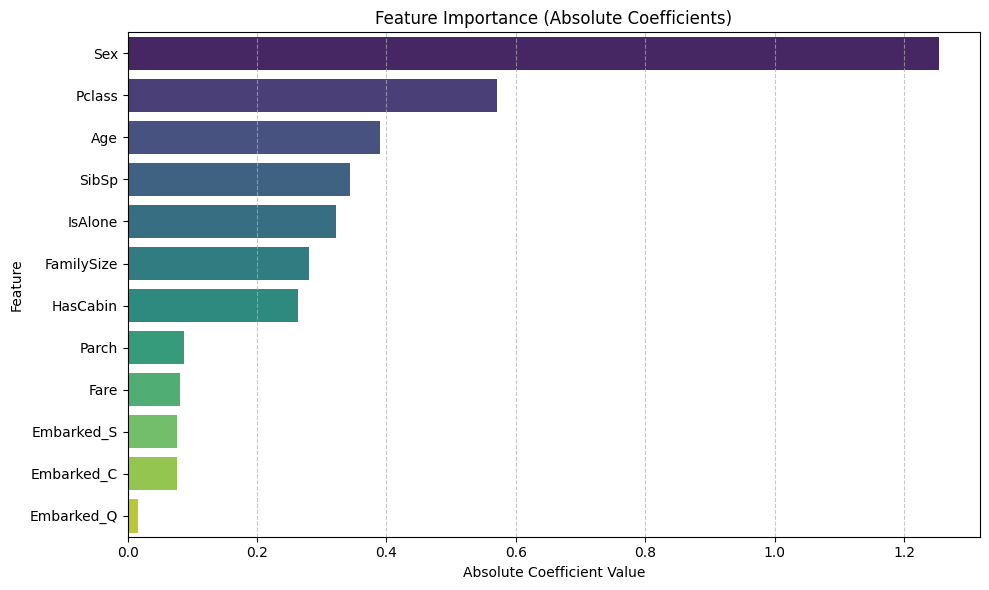

'\nnext box\n'

In [ ]:
# TODO: Extract model coefficients
'''
We already have the 'coefficients' DataFrame from previous steps
'''

# Create importance_df from coefficients and calculate absolute coefficient
importance_df = coefficients.copy()
importance_df['Abs_Coefficient'] = importance_df['Coefficient'].abs()

# TODO: Rank features by their influence on survival prediction
importance_df = importance_df.sort_values(by='Abs_Coefficient', ascending=False)
print("Feature Ranking (by absolute influence):")
display(importance_df)

# TODO: Create feature importance visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Abs_Coefficient', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance (Absolute Coefficients)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# TODO: Interpret the results and provide insights
'''
next box
'''

### <font color='red'>**Insights from Feature Importance:**</font>

*   **Sex**: This is by far the most influential feature, indicating a strong correlation with survival. Females had a much higher chance of survival.
*   **Pclass (Passenger Class)**: This is the second most influential feature. A lower passenger class (e.g., Pclass=3) had a negative impact on survival, suggesting lower survival rates for those in third class.
*   **Age**: Age also plays a significant role. A negative coefficient suggests that older passengers had a slightly lower chance of survival.
*   **SibSp (Number of Siblings/Spouses Aboard)** and **IsAlone**: These features have a notable negative impact. This implies that traveling with too many siblings/spouses or being completely alone might have decreased survival chances compared to being with a small family.
*   **FamilySize**: This feature is also important, reinforcing the idea that a certain family size was crucial for survival.
*   **HasCabin (Presence of a Cabin)**: This had a positive but smaller influence, indicating that having a cabin might slightly improve survival chances.
*   **Fare**: Fare had a positive but relatively minor impact, suggesting that paying a higher fare might correlate with slightly better survival odds, possibly due to class or location on the ship.
*   **Embarked (Port of Embarkation)**: The embarkation location shows less influence compared to other features, with 'C' (Cherbourg) having a small positive impact and 'S' (Southampton) having a small negative impact.

## 📝 Evaluation Criteria

Your homework will be evaluated based on:

1. **Implementation Correctness (40%)**
   - Proper data preprocessing and handling of missing values
   - Correct implementation of logistic regression
   - Appropriate feature engineering and selection
   - Proper train-test split methodology

2. **Model Performance (30%)**
   - Reasonable classification metrics (accuracy, precision, recall, F1-score)
   - Proper evaluation methodology
   - Analysis of model performance

3. **Code Quality and Analysis (20%)**
   - Clean, readable code with appropriate comments
   - Comprehensive exploratory data analysis
   - Good coding practices and organization

4. **Feature Importance Analysis (10%)**
   - Identification of most important survival factors
   - Clear interpretation of model coefficients
   - Meaningful insights and conclusions